# MCXCor Processing
This is a production workflow to run the multichannel correlation algorithm to estimate travel time residuals, relative amplitudes, and a robust beam (stack) from each ensemble.   The notebooks assumes data to be run have be preprocessed with the notebook "MCXcor_Data_Preparation" or something with similar functionality.  

First, we create the database handle as usual.   Note this is a serial job so I only create the DBClient instance.  If converted to parallel this needs to be more of the standard incantation.  I used this because I was having an issue with my local copy in testing this notebook.

In [1]:
from mspasspy.db.client import DBClient
dbclient=DBClient()
db = dbclient.get_database("MCXcorTesting")

Now a long list of imports:

In [2]:
from mspasspy.db.normalize import ObjectIdMatcher
from mspasspy.util.seismic import print_metadata,sort_ensemble
from mspasspy.ccore.seismic import Seismogram,SeismogramEnsemble,TimeSeriesEnsemble
from mspasspy.ccore.utility import Metadata,ErrorSeverity
from mspasspy.algorithms.MCXcorStacking import (MCXcorPrepP,
      align_and_stack,
      beam_coherence,
      beam_correlation,
      phase_time,
      amplitude_relative_to_beam,
      post_MCXcor_metrics,
      demean_residuals,
)
from mspasspy.ccore.algorithms.basic import TimeWindow
from mspasspy.algorithms.basic import ExtractComponent
from mspasspy.algorithms.signals import filter
from mspasspy.algorithms.snr import filter_by_snr_bandwidth
import numpy as np

In [3]:
def discard_alaska_stations(e):
    """
    Crude function for test data to remove stray station from Alaska that contaminated the data set. 
    Not at all generic and should be discarded if this notebook is adapted for other data sets.
    """
    eout = SeismogramEnsemble(Metadata(e),len(e.member))
    for d in e.member:
        if d['site_lat'] < 52.0:
                eout.member.append(d)
    if len(eout.member)>0:
        eout.set_live()
    return eout

def save_beam(db,beam,ensemble,data_tag="Pbeam"):
    """
    Save beam to wf_TimeSeries adding a list of ObjectIds from the ensemble.
    Note this algorithm is not portable.  The object Ids are valid only because 
    ExtractComponents preserves them and nothing in this notebook changes it.  
    The big warning is an intermediate save of ensemble would invalidate the 
    link back to the original wf_Seismogram records.

    Returns the id of the saved datum
    """
    if beam.dead() or ensemble.dead():
        return None
    idlist =[]
    for d in ensemble.member:
        if d.live:
            idlist.append(d['_id'])
    beam['wflist']=idlist
    wfid_saved = db.save_data(beam,collection='wf_TimeSeries',data_tag=data_tag)
    return wfid_saved
def save_xcor_arrivals(db,ensemble,collection="arrival_xcor"):
    """
    Saves attributes computed by post_MCXcor_metrics to a scratch collection 
    I'll call arrival_xcor.  The names are fragile so are handled a bit carefully.
    """
    keylist=["Ptime_xcor",
             "beam_correlation",
             "beam_coherence",
             "beam_relative_amplitude",
             "Presidual","Ptime",
             "Ptime_xcor",
             "Pmeasured",
             "Presidual_bias",
             "robust_stack_weight",
             "source_id",
             "site_id",
            ]
    # use a list to reduce database transaction overhead
    doclist=[]
    # silently ignore any key-value pairs not defined in a member
    for d in ensemble.member:
        if d.live:
            doc=dict()
            for key in keylist:
                if d.is_defined(key):
                    doc[key] = d[key]
            # always post this one 
            doc['wf_Seismogram_id']=d['_id']
        doclist.append(doc)
    collection = db[collection]
    idlist=collection.insert_many(doclist)
    return idlist


This is the processing block.   I'll add to this later after I hack on it for a while.

In [4]:
site_matcher = ObjectIdMatcher(db,collection='site',attributes_to_load=['lat','lon','elev'])
source_matcher = ObjectIdMatcher(db,collection='source',
                                 attributes_to_load=['lat','lon','depth','time'],
                                 load_if_defined=['magnitude'],
                                )
srcids=db.wf_Seismogram.distinct('source_id')
nsrc=len(srcids)
print("This run will process ",nsrc,
      " common source gathers")
count = 0
# for testing here - align_and_stack needs this as an optional argument
min_size=4
for sid in srcids:
    # this data tag is what is used by the preprocessing script - change likely needed if adapted
    query={'source_id' : sid,
           'data_tag' : 'preprocessed',
           }
    n = db.wf_Seismogram.count_documents(query)
    if n<=min_size:
            print("source_id={} has only {} members - skipped".format(sid,n))
            count += 1
            continue
    print("working on source_id=",sid," with number of members=",n)
    srcdoc = db.source.find_one({'_id' : sid})
    print("source magnitude=",srcdoc['magnitude'])
    print(srcdoc['lat'],srcdoc['lon'],srcdoc['depth'])
    cursor = db.wf_Seismogram.find(query)
    e = db.read_data(cursor,
                     collection='wf_Seismogram',
                     normalize=[site_matcher,source_matcher])
    e = discard_alaska_stations(e)
    print("Working ensemble of size=",len(e.member))
    nw = TimeWindow(-200.0,-10.0)
    e = ExtractComponent(e,2)
    # important to realize this function assumes the data have been passed through 
    # broadband_snr_QC
    [e,beam0] = MCXcorPrepP(e,nw,station_collection='site')
    # TODO:  using a fixed robust window - may want to test the auto setting function
    rw = TimeWindow(-3.0, 30.0) 
    if e.dead():
        print("ensemble was marked dead - error log size=",e.elog.size())
        print("error log content")
        for entry in e.elog.get_error_log():
                print(entry.message,entry.badness)
    [e,beam] = align_and_stack(e,beam0)
    if beam.dead():
        print("align_and_stack failed;  error log:")
        for entry in beam.elog.get_error_log():
          print(entry.message,entry.badness)
        continue
    nlive=0
    for i in range(len(e.member)):
        if e.member[i].live:
            e.member[i] = post_MCXcor_metrics(e.member[i],beam)
            nlive += 1
    print("Number live members in ensemble returned by align_and_stack=",nlive)
    e = demean_residuals(e)
    print("demean_residuals estimate of center correction=",e["Presidual_bias"])
    idlist=save_xcor_arrivals(db,e)
    save_beam(db,beam,e)
    count += 1

This run will process  0  common source gathers


## Explore Arrival Estimates
The objective here is to examine the outputs stored in the prototype "arrival_xcor" collection.   The results will be a set of graphics to visualize the results.

### Residuals
First, plot histograms of all the computed residuals.

Total number of computed arrivals= 0


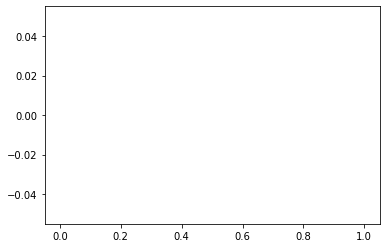

In [5]:
import matplotlib.pyplot as plt
import numpy as np
ntotal=db.arrival_xcor.count_documents({})
r = np.zeros(ntotal)
print("Total number of computed arrivals=",ntotal)
cursor=db.arrival_xcor.find({})
i = 0
for doc in cursor:
    r[i] = doc['Presidual']
    i += 1
plt.hist(r)
plt.show()

Replot excluding residuals larger than abs(2.5)

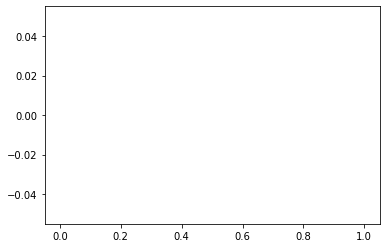

In [6]:
re=[]
for x in r:
    if abs(x)<2.5:
        re.append(x)
plt.hist(re)
plt.show()

### Coherence measures
Now plot histograms of the different coherence metrics.

Total number of computed arrivals= 0


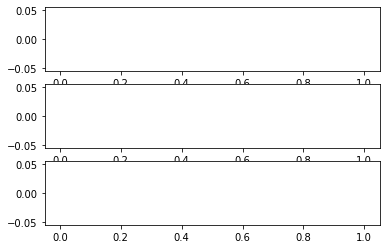

In [7]:
ntotal=db.arrival_xcor.count_documents({})
coh = np.zeros(ntotal)
xc = np.zeros(ntotal)
amp = np.zeros(ntotal)
print("Total number of computed arrivals=",ntotal)
cursor=db.arrival_xcor.find({})
i = 0
for doc in cursor:
    coh[i] = doc['beam_coherence']
    # temporary abs to handle a bug in MCXcor function that computes this
    xc[i] = abs(doc['beam_correlation'])
    amp[i] = doc['beam_relative_amplitude']
    i += 1
fig,ax = plt.subplots(3)
ax[0].hist(coh)
ax[1].hist(xc)
ax[2].hist(amp)
plt.show()

Some cross plots are of interest.

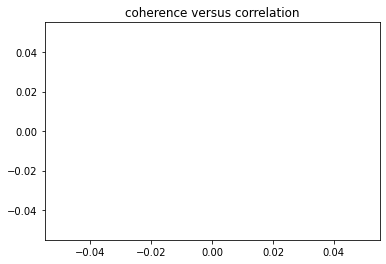

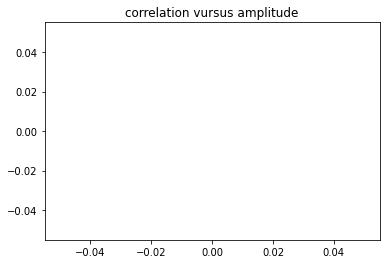

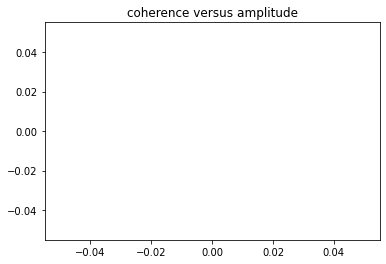

In [8]:
plt.plot(xc,coh,'o')
plt.title("coherence versus correlation")
plt.show()
plt.plot(amp,xc,'o')
plt.title('correlation vursus amplitude')
plt.show()
plt.plot(amp,coh,'o')
plt.title("coherence versus amplitude")
plt.show()